In [13]:
import matplotlib.pyplot as plt
import json
import numpy as np
import pickle as pkl

### Exp 1: XY4

In [2]:
filename = 'exp_data/XY4_ManuallyProcessed.json'
with open(filename, 'r') as file:
    xy4_data = json.load(file)

In [3]:
xy4_data.keys()

dict_keys(['params', 'title', 'startPos', 'posTracking', 'xlabel', 'ylabel', 'datasets'])

In [4]:
xy4_data['datasets'].keys()

dict_keys(['tau_InterPiOver2', 'plusPi/2_cts', 'minusPi/2_cts', 'sumPlusCts', 'sumMinusCts', 'sumDiffs', 'contrasts'])

Text(0, 0.5, 'contrast/coherence')

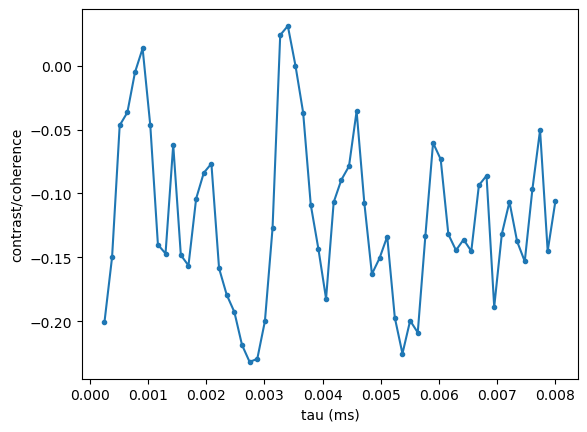

In [5]:
plt.plot(np.array(xy4_data['datasets']['tau_InterPiOver2'])/1e6, np.array(xy4_data['datasets']['contrasts']), '.-')
plt.xlabel('tau (ms)')
plt.ylabel('contrast/coherence')

In [15]:
def normalize_coherence(contrast, baseline=None):
    """
    Normalize DD contrast data into a coherence-like signal.

    Parameters
    ----------
    contrast : np.ndarray
        1D array of contrast data.
    baseline : float or None
        Long-time offset C_inf.
        If None, estimated from the last 10% of points.

    Returns
    -------
    coherence : np.ndarray
        Normalized coherence:
            L = (C - C_inf) / (C0 - C_inf)
    """

    contrast = np.asarray(contrast)

    # Estimate long-time baseline from last 10% of data
    if baseline is None:
        n_tail = max(1, len(contrast) // 10)
        baseline = np.mean(contrast[-n_tail:])

    # Initial value
    c0 = contrast[0]

    # Avoid divide-by-zero
    denom = c0 - baseline
    if np.isclose(denom, 0):
        raise ValueError("Initial contrast equals baseline; normalization ill-defined.")

    coherence = (contrast - baseline) / denom

    return coherence

In [16]:
contrast = np.array(xy4_data['datasets']['contrasts'])
coherence = normalize_coherence(contrast)

Text(0, 0.5, 'contrast/coherence')

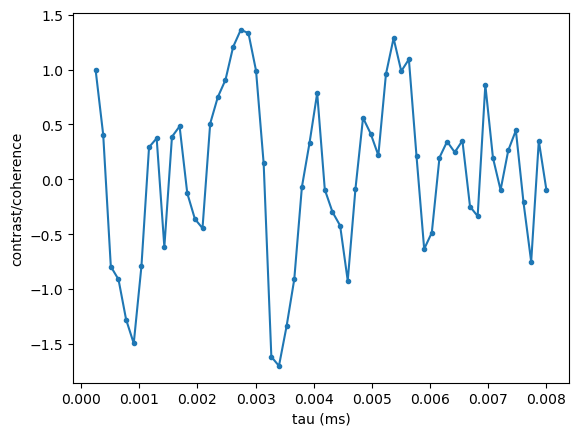

In [8]:
plt.plot(np.array(xy4_data['datasets']['tau_InterPiOver2'])/1e6, coherence, '.-')
plt.xlabel('tau (ms)')
plt.ylabel('contrast/coherence')

In [9]:
def robust_normalize_contrast(
    contrast,
    baseline_percentile=50,
    upper_percentile=95,
    lower_percentile=5,
):
    """
    Robust normalization for DD contrast data when C(0) is unavailable.

    Parameters
    ----------
    contrast : np.ndarray
        1D contrast array.

    baseline_percentile : float
        Percentile used for offset estimation.
        50 = median.

    upper_percentile : float
        Upper percentile for amplitude estimate.

    lower_percentile : float
        Lower percentile for amplitude estimate.

    Returns
    -------
    coherence : np.ndarray
        Robustly normalized signal.
    """

    contrast = np.asarray(contrast)

    # Estimate offset/baseline
    baseline = np.percentile(contrast, baseline_percentile)

    # Robust amplitude estimate
    p_high = np.percentile(contrast, upper_percentile)
    p_low = np.percentile(contrast, lower_percentile)

    amplitude = (p_high - p_low) / 2

    if np.isclose(amplitude, 0):
        raise ValueError("Estimated amplitude is too small.")

    coherence = (contrast - baseline) / amplitude

    return coherence

In [10]:
robust_norm_coherence = robust_normalize_contrast(contrast)

Text(0, 0.5, 'contrast/coherence')

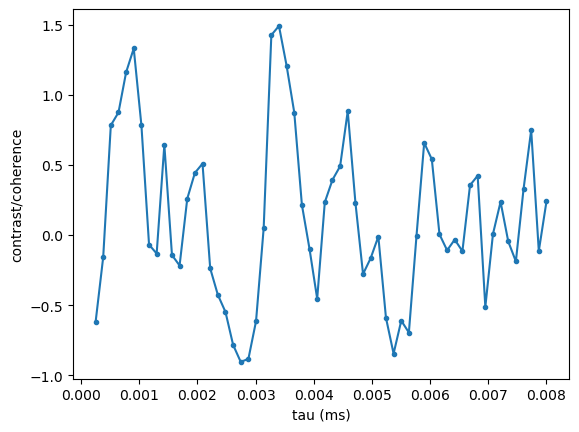

In [11]:
plt.plot(np.array(xy4_data['datasets']['tau_InterPiOver2'])/1e6, robust_norm_coherence, '.-')
plt.xlabel('tau (ms)')
plt.ylabel('contrast/coherence')

In [19]:
with open('exp_data/XY4_exp1_time.pkl', 'wb') as file:
    pkl.dump(np.array(xy4_data['datasets']['tau_InterPiOver2'])/1e6, file)

with open('exp_data/XY4_exp1_coherence.pkl', 'wb') as file:
    pkl.dump(coherence, file)